In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
##Load Dataset

#The dataset contains medical attributes such as age, cholesterol, blood pressure, and heart rate used to predict the presence of heart disease.

In [5]:
df = pd.read_csv('C:/Users/AR/OneDrive/Desktop/python project/heart.csv')#update the path according to your system
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
#Data Understanding

df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
##Data Cleaning

#The dataset was clean with no missing values. Duplicate records were checked and removed if present.

In [9]:
# check missing values
df.isnull().sum()

# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

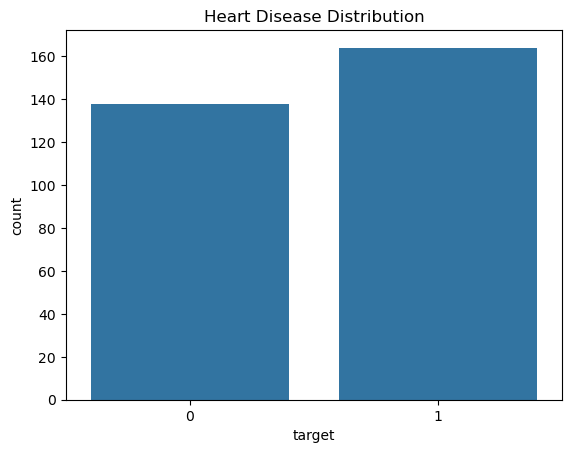

In [11]:
#Target Variable Distribution

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

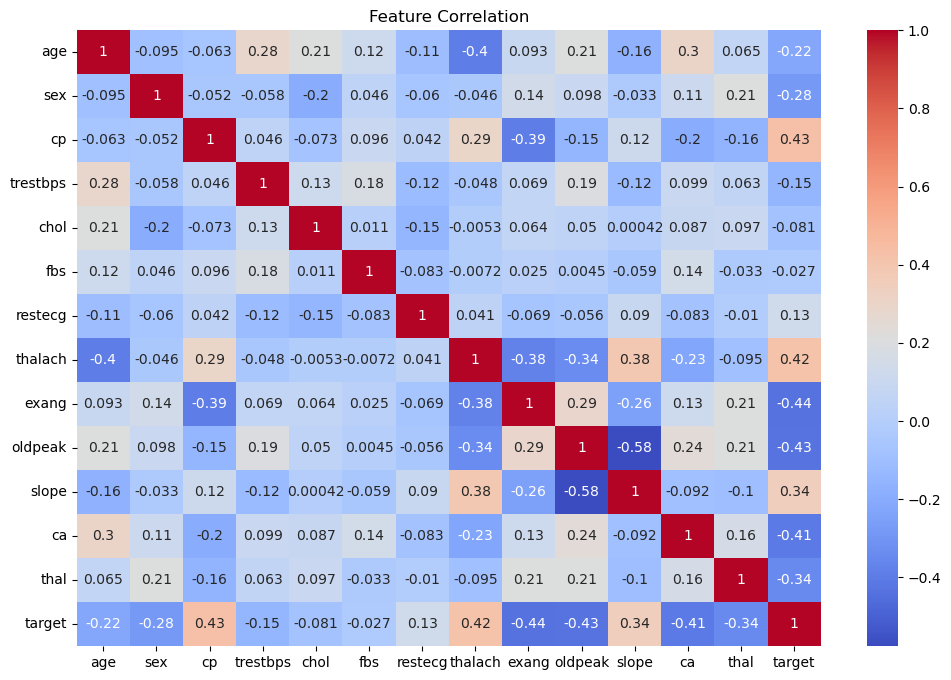

In [13]:
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

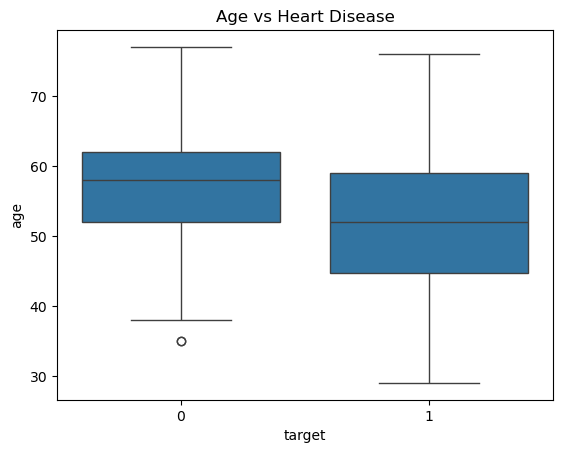

In [15]:
#Age vs Heart Disease

sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

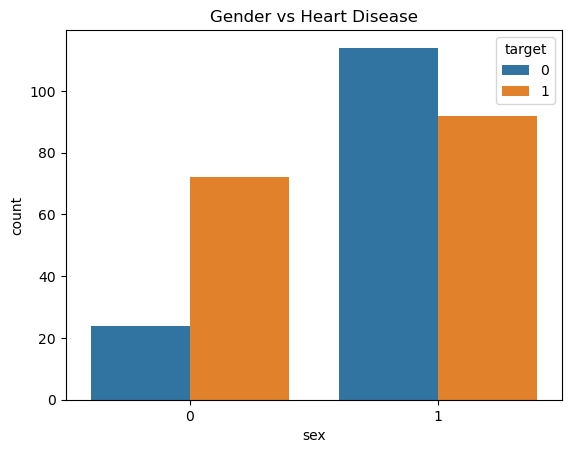

In [17]:
#Gender vs Heart Disease

sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Heart Disease")
plt.show()

In [ ]:
The dataset is balanced between patients with and without heart disease.
Age shows a noticeable impact on heart disease occurrence.
Features such as chest pain (cp), maximum heart rate (thalach), and exercise-induced angina (exang) are strongly related to heart disease.
Correlation heatmap shows important relationships among variables.

In [19]:
#Feature Selection

X = df.drop('target', axis=1)
y = df['target']

In [21]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
#Model Training (Logistic Regression)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
#Predictions

y_pred = model.predict(X_test)

In [27]:
#Model Evaluation

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8032786885245902


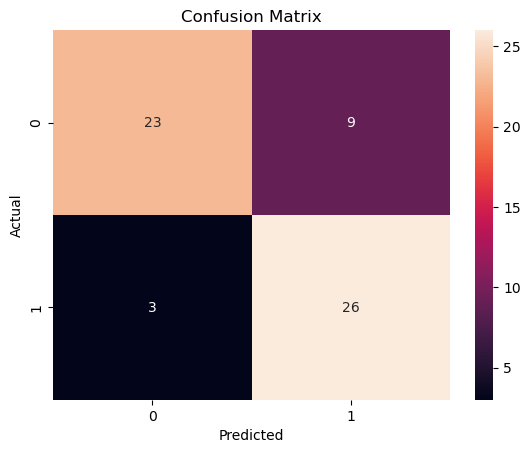

In [29]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

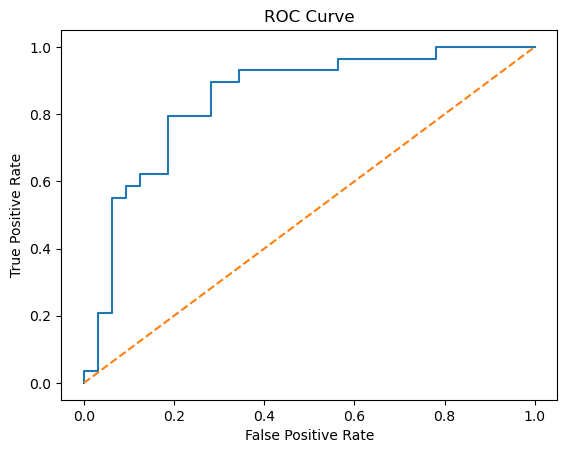

AUC Score: 0.8459051724137931


In [31]:
#ROC Curve & AUC Score

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

In [33]:
#Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
2,cp,0.961832
6,restecg,0.855579
10,slope,0.475142
7,thalach,0.022160
4,chol,-0.001287
0,age,-0.003979
3,trestbps,-0.033232
5,fbs,-0.124568
8,exang,-0.488065
11,ca,-0.571188


In [ ]:
The most important features affecting heart disease prediction include:

Chest pain type (cp)
Maximum heart rate (thalach)
Exercise-induced angina (exang)

In [35]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7868852459016393


In [ ]:
#Conclusion 

In this project, a machine learning model was developed to predict heart disease using medical data. 
The dataset was cleaned and analyzed using exploratory data analysis techniques.
A Logistic Regression model was trained and evaluated, achieving good accuracy and ROC-AUC score. 
The results indicate that features such as chest pain type, heart rate, and exercise-induced angina play a significant role in predicting heart disease. 
This model can assist in early detection and medical decision-making.